Task:
--------------------
Predict precipiation from temperature, wind and humidity at the surface.
Explore a feedforward neural network (MLP).  

Architecture Summary:
--------------------
- Input: Temperature, wind (u, v components), humidity (specific or relative) at the surface. Not precipitation.
- Output: Precipitation (continuous)
- Model: Start with 3-5 layer MLP with ReLU activation, batch normalization, and dropout for regularization.
- Loss: MSE (for regression).
- Optimizer: Adam


1. Load libraries

2.  Data Loading
WeatherBench2 (ERA5 prepared for ML tasks) provides a standardized dataset for weather prediction.
You can load the data directly from the WeatherBench Google Cloud Storage (GCS).

In [1]:
# 0. How do we ensure reproducibility across runs?
#    Here we fix all relevant random number generators used by Python,
#    NumPy, and PyTorch so that experiments are repeatable given the same
#    configuration. Setting cuDNN to deterministic mode further enforces
#    reproducible GPU behaviour, at the cost of potential performance
#    reductions.


import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [37]:
# ===========================
# Download WeatherBench2 ERA5 from GCS → xarray → PyTorch
# w/ explicit anonymous access (Colab-safe)
# ===========================

import xarray as xr
import gcsfs

# ---------------------------
# 1. Create anonymous GCS filesystem
# ---------------------------
fs = gcsfs.GCSFileSystem(token="anon")

zarr_path = (
    "weatherbench2/datasets/era5/"
    "1959-2023_01_10-6h-64x32_equiangular_conservative.zarr"
)

# IMPORTANT: pass filesystem explicitly
era5_ds = xr.open_zarr(
    fs.get_mapper(zarr_path),
    consolidated=True,
)

era5_ds

<xarray.Dataset> Size: 175GB
Dimensions:                                           (time: 93544,
                                                       longitude: 64,
                                                       latitude: 32, level: 13)
Coordinates:
  * latitude                                          (latitude) float64 256B ...
  * level                                             (level) int64 104B 50 ....
  * longitude                                         (longitude) float64 512B ...
  * time                                              (time) datetime64[ns] 748kB ...
Data variables: (12/62)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_dewpoint_temperature                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    above_ground                                      (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    ...                                                ...
    volumetric_soil_water_layer_1                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_2                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_3                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_4                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    vorticity                                         (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>

3. Preprocess Data Select variables: temperature (t2m), wind (u10, v10), humidity (r2), and precipitation (tp).


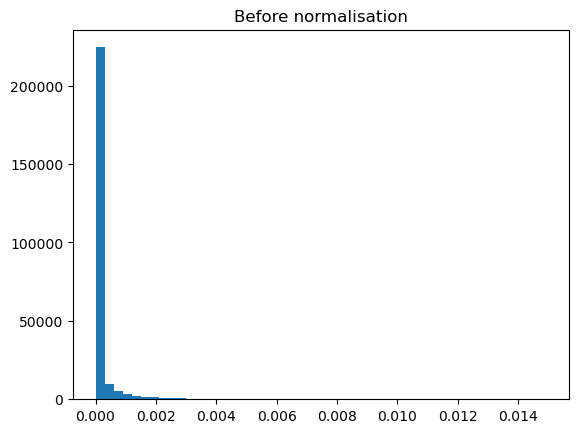

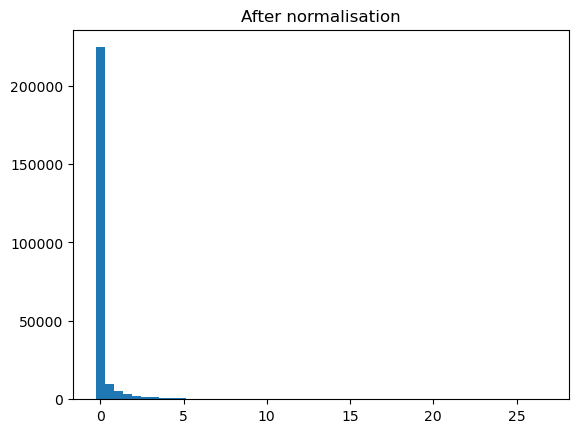

In [133]:
# ---------------------------
# 2. Select ERA5 variables (keys: names in GCS, values: names in Copernicus ERA5)
# ---------------------------
var_map = {
    "2m_temperature": "t2m",
    "10m_u_component_of_wind": "u10",
    "10m_v_component_of_wind": "v10",
    "total_cloud_cover": "tcc",
    "total_precipitation_6hr": "tp",
}

full_ds = era5_ds[list(var_map.keys())].rename(var_map)

# Restrict time for Colab sanity
ds = full_ds.sel(time=slice("2018-01-01", "2018-01-31"))   # change to a later date e.g. "2022-01-31"

# ---------------------------
# 3. Convert precipitation to 6-hourly rate (important)
# ---------------------------
ds["tp"] = ds["tp"].diff("time").clip(min=0)

# Drop first timestep introduced by diff
ds = ds.isel(time=slice(1, None))

# ---------------------------
# 4. Normalisation
# ---------------------------

# Visualise the distribution before/after the normalisation for one variable
import matplotlib.pyplot as plt

plt.hist(ds["tp"].values.flatten(), bins=50)
plt.title("Before normalisation")
plt.show()

training_norms = dict()

for v in ds.data_vars:
    mean = ds[v].mean(dim=("time", "latitude", "longitude"))
    std  = ds[v].std(dim=("time", "latitude", "longitude"))
    ds[v] = (ds[v] - mean) / std

    training_norms[v] = (mean, std)


plt.hist(ds["tp"].values.flatten(), bins=50)
plt.title("After normalisation")
plt.show()


In [134]:

# ---------------------------
# 5. Convert to PyTorch tensors
# ---------------------------
# Shape: (variables, time, lat, lon)
data = torch.tensor(ds.to_array().values, dtype=torch.float32)

# Inputs and target
X = data[:4]     # t2m, u10, v10, d2m
y = data[4]      # tp

# Flatten spatio-temporal grid
X = X.permute(1, 2, 3, 0).reshape(-1, 4)
y = y.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

# ---------------------------
# 6. Train–test split
# ---------------------------
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

grid_size=64*32
X_plot = X[-grid_size:]
y_plot = y[-grid_size:]

print("Train samples:", len(X_train))
print("Test samples :", len(X_test))

X shape: torch.Size([251904, 4])
y shape: torch.Size([251904, 1])
Train samples: 201523
Test samples : 50381


3. Define the Model

In [136]:
# ---------------------------
# 7. Define a feedforward MLP for precipitation prediction
#    This network maps local near-surface meteorological features
#    (2 m temperature, 10 m winds, and total cloud cover)
#    to 6-hourly precipitation, using a moderately deep architecture
#    with batch normalisation and dropout to stabilise training and
#    reduce overfitting on flattened spatio-temporal ERA5 samples.
# ---------------------------

import torch.nn as nn
from torch.nn import ReLU as  ReLU

class PrecipitationPredictor(nn.Module):
    def __init__(self, input_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), # the first layer is linear (4 features, 64 neurons)
            ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = PrecipitationPredictor()

# [0] Explain: Why we need Dropout and BatchNorm layers here?

# [1] Why 64 hidden layer size?
# is a common "power of 2" choice for hidden layer sizes (e.g., 32, 64, 128, 256).
# It’s large enough to capture complex patterns, but not so large as to cause overfitting or slow down training.
# In practice, you can experiment with 32, 64, 128, etc., but 64 is a good starting point for many tasks.

# [2] Can the batch size (number of samples per gradient update) be different from the number of hidden layers?

# [3] Why BatchNorm and Dropout?
# Batch Normalization helps stabilize and accelerate training by normalizing layer inputs.
# Dropout is a regularization technique that helps prevent overfitting by randomly setting a fraction of input units to zero during training.


4. Train the Model

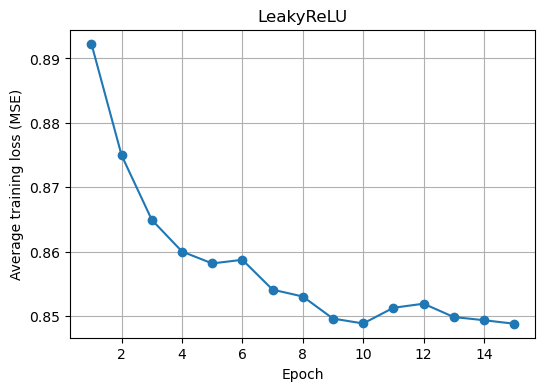

Epoch 15, Avg Loss: 0.8488


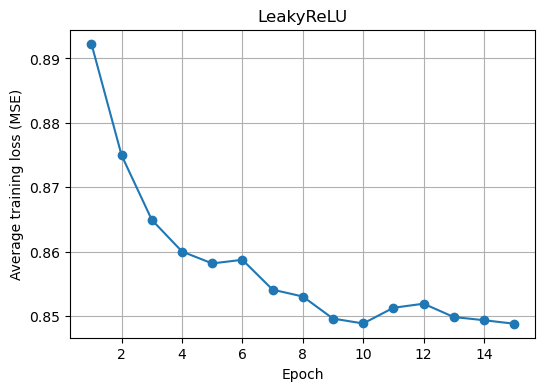

In [137]:
# ---------------------------
# 8. How does the model learn during training, and why do we follow the
#    sequence optimizer.zero_grad() → loss.backward() → optimizer.step()?
#    In this section, we train the MLP using mini-batch gradient descent,
#    track optimisation progress with tqdm, and visualise convergence
#    by updating the training loss curve after each epoch.
# ---------------------------

import matplotlib.pyplot as plt

from IPython.display import clear_output, display
from torch.utils.data import DataLoader
from tqdm import tqdm


# Loss function and optimiser
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Device handling: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# DataLoader
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ---------------------------
# Training with live loss plot
# ---------------------------
num_epochs = 15      # increase the number
epoch_losses = []

plt.ion()  # interactive mode for live updates
fig, ax = plt.subplots(figsize=(6, 4))
line, = ax.plot([], [], marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average training loss (MSE)")
ax.set_title("Training loss convergence")
ax.grid(True)

for epoch in range(num_epochs):

    epoch_loss = 0.0
    n_batches = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs}",
        dynamic_ncols=True,
    )

    for X_batch, y_batch in progress_bar:
        X_batch = X_batch.to(device) # 1 mini-batch of input features, shape [batch_size, 4]
        y_batch = y_batch.to(device) # corresponding precipitation targets, shape [batch_size, 1]

        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Backpropagation and parameter update
        optimizer.zero_grad()   # clears accumulated gradients
        loss.backward()         # computes gradients via chain rule
        optimizer.step()        # updates parameters using Adam

        # Accumulate statistics
        epoch_loss += loss.item()
        n_batches += 1

        progress_bar.set_postfix(
            batch_loss=f"{loss.item():.4f}"
        )

    avg_loss = epoch_loss / n_batches if n_batches > 0 else float("nan")
    epoch_losses.append(avg_loss)

    # ---- Live plot update ----
    clear_output(wait=True)
    ax.clear()
    ax.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Average training loss (MSE)")
    ax.set_title('LeakyReLU')
    ax.grid(True)
    display(fig)

    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")


5. Evaluate the Model

In [50]:
# ---------------------------
# 9. How well does the trained model generalise to unseen data?
#    In this section, we evaluate the trained MLP on a held-out test set.
#    The model is switched to evaluation mode to disable dropout and fix
#    batch normalisation statistics, and inference is performed without
#    gradient tracking to reduce memory usage and ensure correctness.
# ---------------------------

# Ensure device is set consistently with training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

criterion = nn.MSELoss()

# Forward pass on test data without gradient tracking
with torch.no_grad():
    X_test_device = X_test.to(device)
    y_test_device = y_test.to(device)

    test_preds = model(X_test_device)
    test_loss = criterion(test_preds, y_test_device)

    print(f"Test Loss (MSE): {test_loss.item():.4f}")

# (optional): Additional evaluation metrics such as MAE, RMSE, or R²
# can be computed here to provide a more interpretable assessment of
# precipitation prediction performance.

Test Loss (MSE): 0.7827


## hyperparameter comparison

### number of layers

In [49]:
## construct nn with arbitrary number of layers
import torch.nn as nn

def construct_layers(n_layers, input_dim = 4, dropout_prop = 0.2, scale_magnitude=4):
    '''
    construct a list of layers to pass into nn.Sequential to form our network; n_layers will be the number of hidden layers + 2

    we would quite like something binomial ideally (i don't actually know what is best) but easiest is just 2**(n-2) and scale down by powers of two each layer.
    '''

    assert n_layers >= 2

    n_hidden = n_layers - 2
    initial_exp = n_hidden + scale_magnitude
    initial_layer_size = 2 ** initial_exp

    layers = [
        nn.Linear(input_dim, initial_layer_size),
        nn.ReLU(),
        nn.BatchNorm1d(initial_layer_size),
        nn.Dropout(dropout_prop)
    ]

    for i in range(n_hidden-1):
        cur_layer_size = 2**(initial_exp - i)
        new_layer_size = cur_layer_size // 2

        ## linear layer
        layers.append(
            nn.Linear(cur_layer_size, new_layer_size)
        )

        ## activation function
        layers.append(
            nn.ReLU()
        )

        ## batch norm
        layers.append(
            nn.BatchNorm1d(new_layer_size)
        )

        ## dropout layer
        layers.append(
            nn.Dropout(dropout_prop)
        )

    ## output layer
    new_layer_size = cur_layer_size // 2

    layers.append(
        nn.Linear(new_layer_size, new_layer_size // 2)
    )

    layers.append(
        nn.ReLU()
    )

    layers.append(
        nn.Linear(new_layer_size // 2, 1)
    )

    layers.append(
        nn.ReLU()
    )

    return layers

def add_layer(n_in, n_out, layers, activation_fn=nn.ReLU, drop_prop=0.2):

    new_layers = layers.copy()

    new_layers.append(nn.Linear(n_in, n_out))
    new_layers.append(activation_fn())
    new_layers.append(nn.BatchNorm1d(n_out))
    new_layers.append(nn.Dropout(drop_prop))

    return new_layers

def construct_layers_new(n_layers, input_dim=4, width=128, activation_fn = nn.ReLU):
    '''
    alternative that keeps nn width at 128
    '''

    assert n_layers > 2 # we want at least 1 hidden layer

    n_hidden = n_layers - 2

    if n_hidden == 1:
        initial_width = width
    
    else:
        initial_width = width // 2

    layers = []

    # initial layer
    layers = add_layer(input_dim, initial_width, layers, activation_fn)
    layers = add_layer(initial_width, width, layers, activation_fn)

    for _ in range(n_hidden-2):
        layers = add_layer(width, width, layers), activation_fn

    ## second-to-last layer
    layers.append(nn.Linear(width, width // 2))
    layers.append(activation_fn())

    ## final layer
    layers.append(nn.Linear(width // 2, 1))

    return layers

class PP_from_layers(nn.Module):
    def __init__(self, n_layers=4, input_dim=4, **construct_layer_kwargs):
        super().__init__()
        layers = construct_layers_new(n_layers, input_dim, **construct_layer_kwargs)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [50]:
## model training

## this bit only needs to be done once
import matplotlib.pyplot as plt

from IPython.display import clear_output, display
from torch.utils.data import DataLoader
from tqdm import tqdm


# Loss function and optimiser
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Device handling: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# DataLoader
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

## hyperparameter
num_epochs = 8      # increase the number

# ---------------------------
# Training with live loss plot
# ---------------------------

def train_model(model, ax, num_epochs=num_epochs, train_loader=train_loader, device=device, criterion=criterion, optimizer=optimizer):
    epoch_losses = []

    for epoch in range(num_epochs):

        epoch_loss = 0.0
        n_batches = 0

        progress_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{num_epochs}",
            dynamic_ncols=True,
        )

        for X_batch, y_batch in progress_bar:
            X_batch = X_batch.to(device) # 1 mini-batch of input features, shape [batch_size, 4]
            y_batch = y_batch.to(device) # corresponding precipitation targets, shape [batch_size, 1]

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backpropagation and parameter update
            optimizer.zero_grad()   # clears accumulated gradients
            loss.backward()         # computes gradients via chain rule
            optimizer.step()        # updates parameters using Adam

            # Accumulate statistics
            epoch_loss += loss.item()
            n_batches += 1

            progress_bar.set_postfix(
                batch_loss=f"{loss.item():.4f}"
            )

        avg_loss = epoch_loss / n_batches if n_batches > 0 else float("nan")
        epoch_losses.append(avg_loss)

        # ---- Live plot update ----
        clear_output(wait=True)
        ax.clear()
        ax.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Average training loss (MSE)")
        ax.grid(True)
        display(fig)

        print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

    return epoch_losses

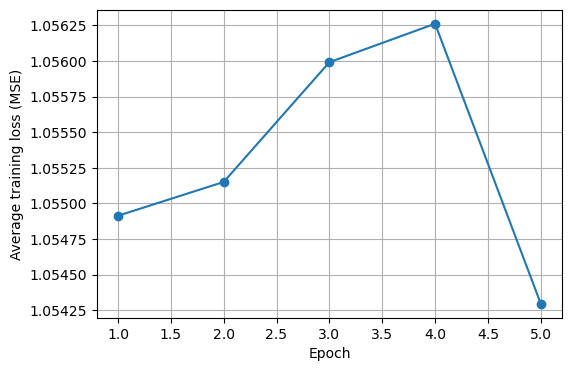

Epoch 5, Avg Loss: 1.0543


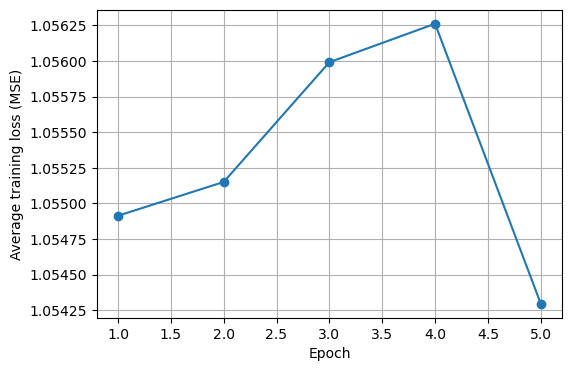

In [51]:
## =======
# ACTIVATION FUNCTION INVESTIGATION
## =======

activation_fn_options = [
    nn.ReLU, nn.LeakyReLU, nn.ELU, nn.Tanh
]
final_errors = []

plt.ion()  # interactive mode for live updates
fig, ax = plt.subplots(figsize=(6, 4))
line, = ax.plot([], [], marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average training loss (MSE)")
ax.set_title("Training loss convergence")
ax.grid(True)

for afunc in activation_fn_options:
    display(f'Training with {afunc} layers')

    model = PP_from_layers(n_layers=4, activation_fn=afunc)

    final_errors.append(train_model(model, ax=ax, num_epochs=5))

In [55]:
final_errors

[[1.0601607037796297,
  1.061791447135296,
  1.0605550602305576,
  1.060100805360993,
  1.061058957781554],
 [1.1315268821512736,
  1.131116594808107,
  1.1342015243550925,
  1.1319318434910268,
  1.132977425793015],
 [1.0486988895855165,
  1.0493698497117985,
  1.0483007840421814,
  1.0476501122325252,
  1.0462423295738508],
 [1.054912889333103,
  1.0551502519621665,
  1.0559914263563333,
  1.056261586232975,
  1.054294883324707]]

Text(0.5, 1.0, 'Performance of different activation functions')

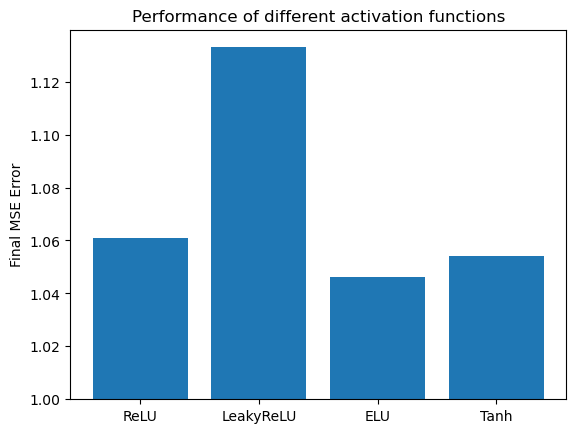

In [63]:
## computed with 3 epochs
## layer sizes are powers of 2

plot_errors = np.array(final_errors)
plot_final_errors = plot_errors[:,-1]

fns = [
    'ReLU', 'LeakyReLU', 'ELU', 'Tanh'
]

#plt.grid(True)
plt.ylabel('Final MSE Error')
plt.bar(fns, plot_final_errors - 1, 0.8, 1)

plt.title('Performance of different activation functions')

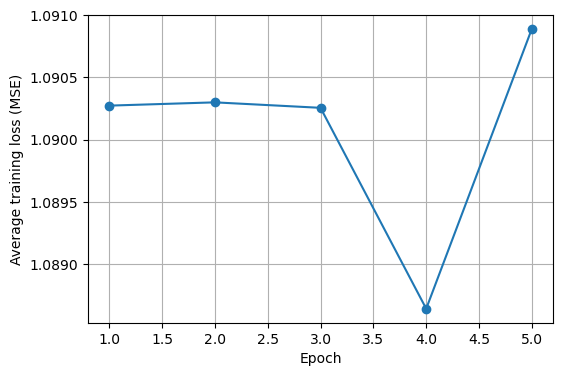

Epoch 5, Avg Loss: 1.0909


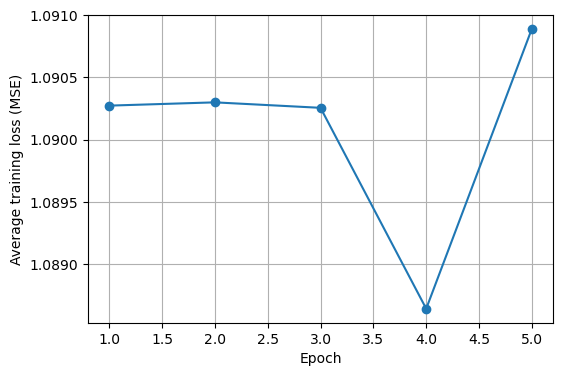

In [46]:
## =======
# N LAYERS INVESTIGATION
## =======

layer_num_values = [4, 6, 8, 10] #list(range(4, 10))
final_errors = []

plt.ion()  # interactive mode for live updates
fig, ax = plt.subplots(figsize=(6, 4))
line, = ax.plot([], [], marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average training loss (MSE)")
ax.set_title("Training loss convergence")
ax.grid(True)

for n_layers in layer_num_values:
    print(f'Training with {n_layers} layers')

    model = PP_from_layers(n_layers)

    final_errors.append(train_model(model, ax=ax, num_epochs=5))

Text(0.5, 1.0, 'Effect of MLP depth on Accuracy')

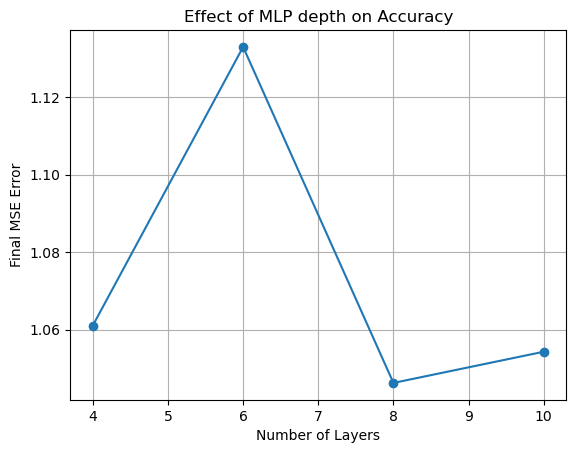

In [52]:
## computed with 3 epochs
## layer sizes are powers of 2

plot_errors = np.array(final_errors)
plot_final_errors = plot_errors[:,-1]

plt.grid(True)
plt.ylabel('Final MSE Error')
plt.xlabel('Number of Layers')
plt.plot(layer_num_values, plot_final_errors, marker='o')

plt.title('Effect of MLP depth on Accuracy')

In [ ]:
with open('./final_errors.txt', 'w') as out_file:
    out_file.write(
        repr(layer_num_values)
    )
    out_file.write('\n')
    out_file.write(
        repr(final_errors)
    )

### dropout percentage

## feature importance
we'll do an ablation analysis first i think

In [17]:
## model training

## this bit only needs to be done once
import matplotlib.pyplot as plt

from IPython.display import clear_output, display
from torch.utils.data import DataLoader
from tqdm import tqdm


# Loss function and optimiser
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Device handling: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## hyperparameter
num_epochs = 6      # increase the number

# ---------------------------
# Training with live loss plot
# ---------------------------

def train_model(model, ax, num_epochs=num_epochs, train_loader=train_loader, device=device, criterion=criterion, optimizer=optimizer):
    model.to(device)
    epoch_losses = []

    for epoch in range(num_epochs):

        epoch_loss = 0.0
        n_batches = 0

        progress_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{num_epochs}",
            dynamic_ncols=True,
        )

        for X_batch, y_batch in progress_bar:
            X_batch = X_batch.to(device) # 1 mini-batch of input features, shape [batch_size, 4]
            y_batch = y_batch.to(device) # corresponding precipitation targets, shape [batch_size, 1]

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backpropagation and parameter update
            optimizer.zero_grad()   # clears accumulated gradients
            loss.backward()         # computes gradients via chain rule
            optimizer.step()        # updates parameters using Adam

            # Accumulate statistics
            epoch_loss += loss.item()
            n_batches += 1

            progress_bar.set_postfix(
                batch_loss=f"{loss.item():.4f}"
            )

        avg_loss = epoch_loss / n_batches if n_batches > 0 else float("nan")
        epoch_losses.append(avg_loss)

        # ---- Live plot update ----
        clear_output(wait=True)
        ax.clear()
        ax.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Average training loss (MSE)")
        ax.grid(True)
        display(fig)

        print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

    return epoch_losses

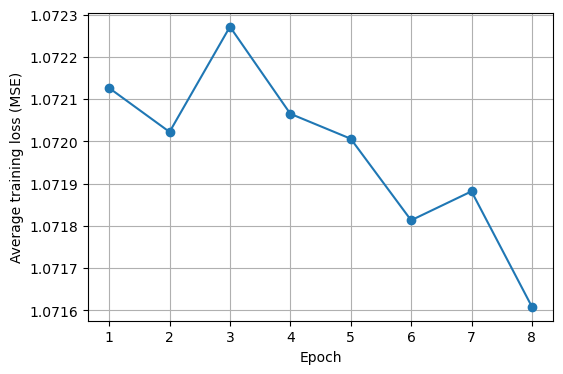

Epoch 8, Avg Loss: 1.0716


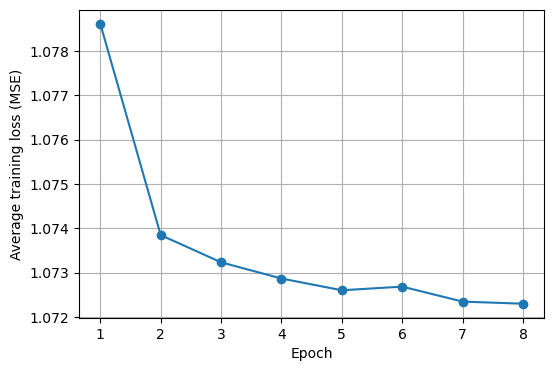

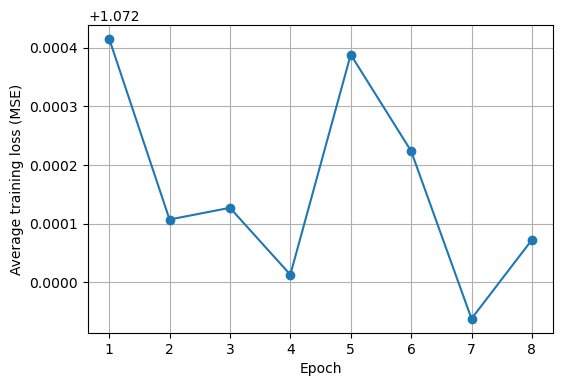

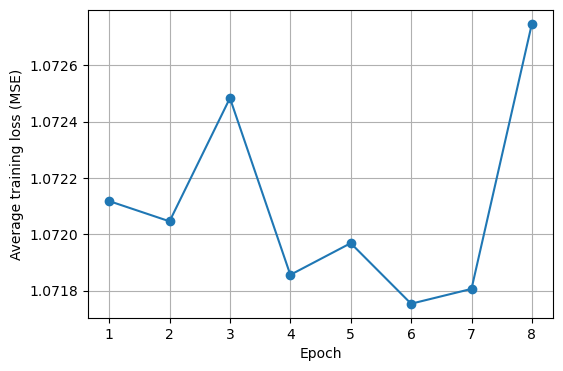

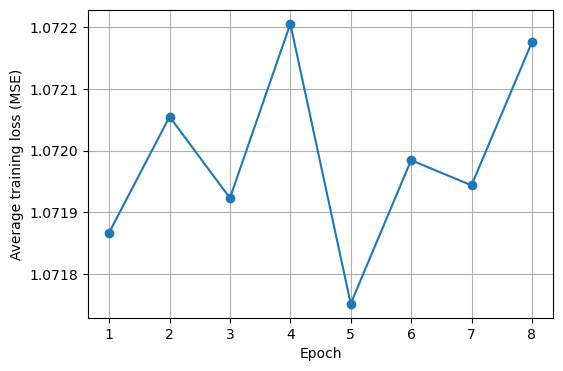

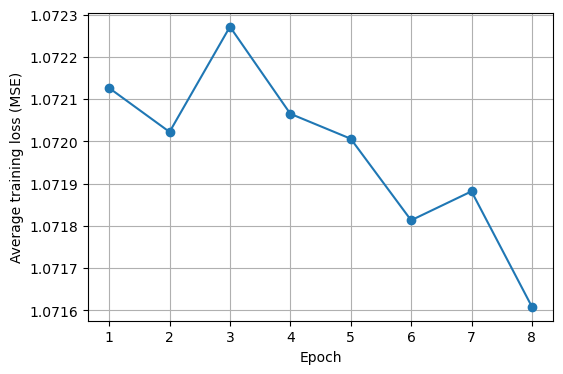

In [18]:
final_losses = []

variables = ['t2m', 'tcc', 'u10', 'v10', '']

for var_num, var in enumerate(variables):
    n_vars = 4
    var_choices = ['t2m', 'tcc', 'u10', 'v10']
    
    if var != '':
        var_choices.remove(var)
        n_vars -= 1

    partial_ds = ds.copy()[var_choices + ['tp']]

    data = torch.tensor(partial_ds.to_array().values, dtype=torch.float32)

    X = data[:n_vars]     # t2m, u10, v10, d2m
    y = data[n_vars]      # tp

    X = X.permute(1, 2, 3, 0).reshape(-1, 4)
    y = y.reshape(-1, 1)

    print("X shape:", X.shape)
    print("y shape:", y.shape)

    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    print("Train samples:", len(X_train))
    print("Test samples :", len(X_test))

    # DataLoader
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

    plt.ion()  # interactive mode for live updates
    fig, ax = plt.subplots(figsize=(6, 4))
    line, = ax.plot([], [], marker="o")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Average training loss (MSE)")
    ax.set_title("Training loss convergence")
    ax.grid(True)

    losses = train_model(model, ax=ax, num_epochs=8)
    final_losses.append(losses[-1])

[1.0722991520054732,
 1.0720720598970956,
 1.0727478016158416,
 1.0721758816653042,
 1.0716085685614203]

Text(0.5, 1.0, 'Effect of removing variables (base MSE: 1.0716)')

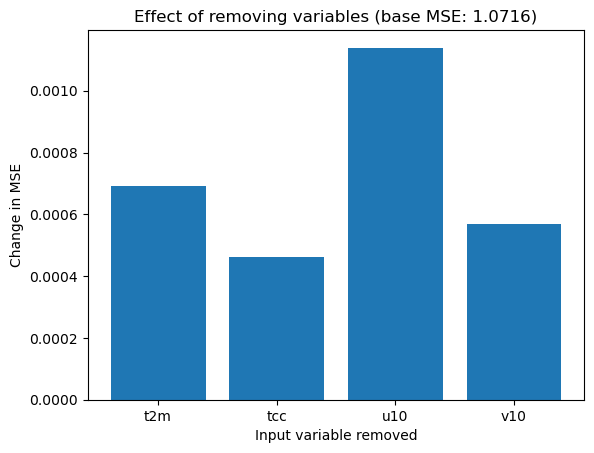

In [27]:
bottom = 1.0712

display(final_losses)

base_loss = final_losses[-1]
vars = variables[:-1]
var_losses = np.array(final_losses[:-1])

plt.bar(vars, var_losses-base_loss)
plt.ylabel('Change in MSE')
plt.xlabel('Input variable removed')
plt.title(f'Effect of removing variables (base MSE: {base_loss:.4f})')

# plt.bar(variables, np.array(final_losses)-bottom, 0.8, bottom)

##### First try

In [2]:
# 0. How do we ensure reproducibility across runs?
#    Here we fix all relevant random number generators used by Python,
#    NumPy, and PyTorch so that experiments are repeatable given the same
#    configuration. Setting cuDNN to deterministic mode further enforces
#    reproducible GPU behaviour, at the cost of potential performance
#    reductions.


import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

import xarray as xr
import gcsfs

# ---------------------------
# 1. Create anonymous GCS filesystem
# ---------------------------
fs = gcsfs.GCSFileSystem(token="anon")

zarr_path = (
    "weatherbench2/datasets/era5/"
    "1959-2023_01_10-6h-64x32_equiangular_conservative.zarr"
)

# IMPORTANT: pass filesystem explicitly
era5_ds = xr.open_zarr(
    fs.get_mapper(zarr_path),
    consolidated=True,
)

era5_ds

<xarray.Dataset> Size: 175GB
Dimensions:                                           (time: 93544,
                                                       longitude: 64,
                                                       latitude: 32, level: 13)
Coordinates:
  * latitude                                          (latitude) float64 256B ...
  * level                                             (level) int64 104B 50 ....
  * longitude                                         (longitude) float64 512B ...
  * time                                              (time) datetime64[ns] 748kB ...
Data variables: (12/62)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_dewpoint_temperature                           (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    above_ground                                      (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    ...                                                ...
    volumetric_soil_water_layer_1                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_2                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_3                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_4                     (time, longitude, latitude) float32 766MB dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    vorticity                                         (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 10GB dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>

In [3]:
## defining inputs
var_map = {
    "2m_temperature": "t2m",
    "10m_u_component_of_wind": "u10",
    "10m_v_component_of_wind": "v10",
    "total_cloud_cover": "tcc",
    "total_precipitation_6hr": "tp",
}

full_ds = era5_ds[list(var_map.keys())].rename(var_map)

# Restrict time for Colab sanity
ds = full_ds.sel(time=slice("2018-01-01", "2018-01-31"))   # change to a later date e.g. "2022-01-31"

ds["tp"] = ds["tp"].diff("time").clip(min=0)

# Drop first timestep introduced by diff
ds = ds.isel(time=slice(1, None))
for v in ds.data_vars:
    mean = ds[v].mean(dim=("time", "latitude", "longitude"))
    std  = ds[v].std(dim=("time", "latitude", "longitude"))
    ds[v] = (ds[v] - mean) / std

ds


<xarray.Dataset> Size: 5MB
Dimensions:    (latitude: 32, longitude: 64, time: 123)
Coordinates:
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * time       (time) datetime64[ns] 984B 2018-01-01T06:00:00 ... 2018-01-31T...
Data variables:
    t2m        (time, longitude, latitude) float32 1MB dask.array<chunksize=(99, 64, 32), meta=np.ndarray>
    u10        (time, longitude, latitude) float32 1MB dask.array<chunksize=(99, 64, 32), meta=np.ndarray>
    v10        (time, longitude, latitude) float32 1MB dask.array<chunksize=(99, 64, 32), meta=np.ndarray>
    tcc        (time, longitude, latitude) float32 1MB dask.array<chunksize=(99, 64, 32), meta=np.ndarray>
    tp         (time, longitude, latitude) float32 1MB dask.array<chunksize=(40, 64, 32), meta=np.ndarray>

In [7]:
class PrecipitationPredictor(nn.Module):
    def __init__(self, input_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), # the first layer is linear (4 features, 64 neurons)
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = PrecipitationPredictor()

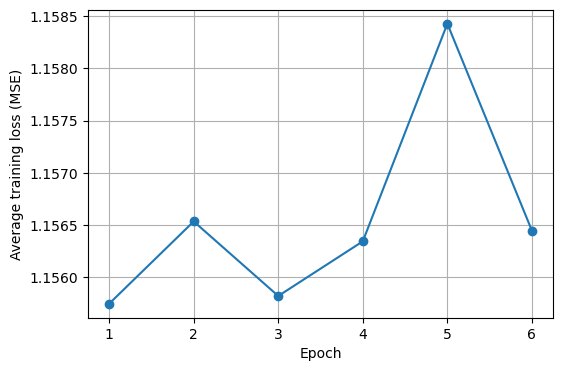

Epoch 6, Avg Loss: 1.1564


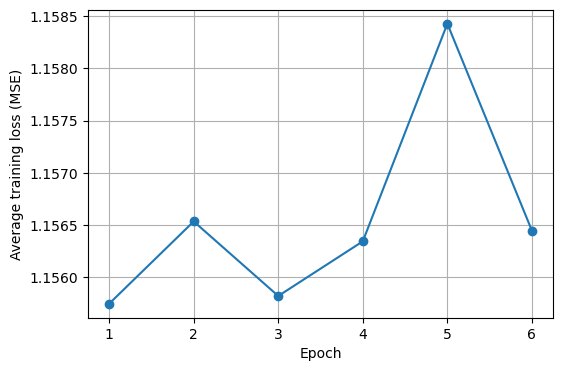

In [12]:
n_vars = 4
variable_list = ['t2m', 'u10', 'v10', 'tcc', 'tp']

variable_list.remove('u10')
n_vars -= 1

partial_ds = ds[variable_list]

data = torch.tensor(partial_ds.to_array().values, dtype=torch.float32)

# Inputs and target

X = data[:n_vars]     # t2m, u10, v10, d2m
y = data[n_vars]      # tp

# Flatten spatio-temporal grid
X = X.permute(1, 2, 3, 0).reshape(-1, 4)
y = y.reshape(-1, 1)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
import matplotlib.pyplot as plt

from IPython.display import clear_output, display
from torch.utils.data import DataLoader
from tqdm import tqdm


# Loss function and optimiser
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Device handling: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# DataLoader
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ---------------------------
# Training with live loss plot
# ---------------------------

model = PrecipitationPredictor()
num_epochs = 6      # increase the number
epoch_losses = []

plt.ion()  # interactive mode for live updates
fig, ax = plt.subplots(figsize=(6, 4))
line, = ax.plot([], [], marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average training loss (MSE)")
ax.set_title("Training loss convergence")
ax.grid(True)

for epoch in range(num_epochs):

    epoch_loss = 0.0
    n_batches = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs}",
        dynamic_ncols=True,
    )

    for X_batch, y_batch in progress_bar:
        X_batch = X_batch.to(device) # 1 mini-batch of input features, shape [batch_size, 4]
        y_batch = y_batch.to(device) # corresponding precipitation targets, shape [batch_size, 1]

        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Backpropagation and parameter update
        optimizer.zero_grad()   # clears accumulated gradients
        loss.backward()         # computes gradients via chain rule
        optimizer.step()        # updates parameters using Adam

        # Accumulate statistics
        epoch_loss += loss.item()
        n_batches += 1

        progress_bar.set_postfix(
            batch_loss=f"{loss.item():.4f}"
        )

    avg_loss = epoch_loss / n_batches if n_batches > 0 else float("nan")
    epoch_losses.append(avg_loss)

    # ---- Live plot update ----
    clear_output(wait=True)
    ax.clear()
    ax.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Average training loss (MSE)")
    ax.grid(True)
    display(fig)

    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")


## Plots n stuff
Plorts

In [82]:
model(X_plot).detach().numpy()

array([[-0.08272447],
       [ 0.20470731],
       [ 0.11667103],
       ...,
       [ 0.02343334],
       [ 0.07120489],
       [ 0.11634988]], shape=(2048, 1), dtype=float32)

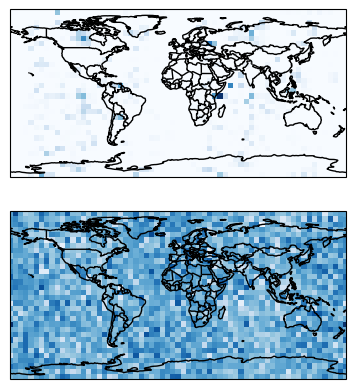

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

fig, axs = plt.subplots(2, 1, subplot_kw={'projection':ccrs.PlateCarree()})
axs = axs.flatten()

lats = ds.latitude
lons = ds.longitude

ax = axs[0]

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND)


y_grid = y_plot.numpy().reshape(32, 64)
y_cyclic, lons_cyclic = add_cyclic_point(y_grid, lons)

ax.pcolormesh(lons_cyclic, lats, y_cyclic, cmap='Blues')

ax = axs[1]

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND)

y_pred = model(X_plot)

y_grid = y_pred.detach().numpy().reshape(32, 64)
y_cyclic, lons_cyclic = add_cyclic_point(y_grid, lons)

ax.pcolormesh(lons_cyclic, lats, y_cyclic, cmap='Blues')

In [97]:
training_norms['tp'][1].compute()

<xarray.DataArray 'tp' ()> Size: 4B
array(0.00055173, dtype=float32)

In [140]:
dpt = full_ds.sel(time='2018-01-31T12:00:00') # datapoint

## normalisation before prediction
for v in dpt.data_vars:
    mean, std = training_norms[v]
    dpt[v] = (dpt[v] - mean.compute()) / std.compute()


data_vals = torch.tensor(dpt.to_dataarray().values, dtype=torch.float32)

X = torch.tensor(dpt[['t2m', 'u10', 'v10', 'tcc']].to_dataarray().values, dtype=torch.float32)
y = torch.tensor(dpt['tp'].values, dtype=torch.float32)

X = X.reshape(-1, 4)
y = y.reshape(-1, 1)

y_predicted = model(X).detach().numpy()
lats = dpt.latitude
lons = dpt.longitude

plot_y_pred = y_predicted.reshape(len(lons), len(lats))
plot_y_true = y.reshape(len(lons), len(lats))

error = np.abs(plot_y_true - plot_y_pred)

C:\Users\nookh\AppData\Local\Temp\ipykernel_16696\304629713.py:24: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  error = np.abs(plot_y_true - plot_y_pred)


Text(0.5, 1.0, 'Forecasted Distribution')

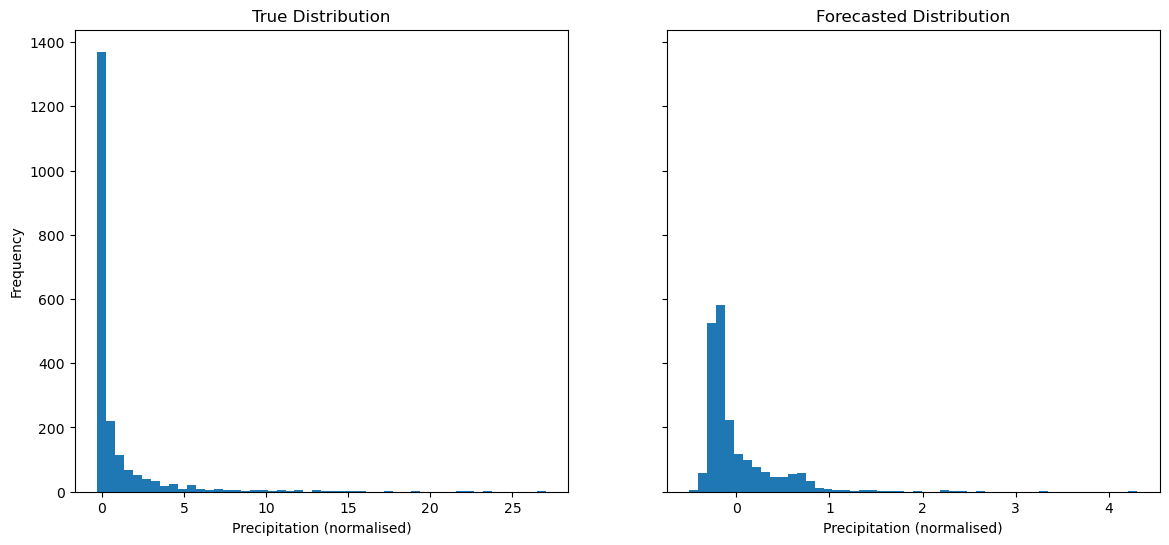

In [141]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True, subplot_kw={'xlabel':'Precipitation (normalised)'})
axs = axs.flatten()

## true distr
ax = axs[0]

ax.hist(y, bins=50)
ax.set_title('True Distribution')
ax.set_ylabel('Frequency')


## predicted
ax = axs[1]
ax.hist(y_predicted, bins=50)
ax.set_title('Forecasted Distribution')

(array([  1.,   2.,   0.,   2.,   2.,   2.,   3.,   5.,   6.,   4.,  10.,
         11.,  13.,  11.,  28.,  22.,  39.,  36.,  58.,  64.,  62.,  74.,
         72., 102.,  87., 125., 143., 113., 107., 116., 123., 122.,  89.,
         73.,  71.,  48.,  52.,  39.,  21.,  23.,  21.,  12.,   6.,   6.,
          4.,   7.,   3.,   5.,   2.,   1.]),
 array([-0.69407243, -0.66772348, -0.64137453, -0.61502558, -0.58867663,
        -0.56232768, -0.53597873, -0.50962979, -0.48328084, -0.45693189,
        -0.43058291, -0.40423396, -0.37788501, -0.35153607, -0.32518712,
        -0.29883817, -0.27248922, -0.24614027, -0.21979132, -0.19344234,
        -0.1670934 , -0.14074445, -0.1143955 , -0.08804655, -0.0616976 ,
        -0.03534865, -0.00899971,  0.01734924,  0.04369819,  0.07004714,
         0.09639609,  0.12274504,  0.14909399,  0.17544293,  0.20179188,
         0.22814083,  0.25448978,  0.28083873,  0.30718774,  0.33353668,
         0.35988563,  0.38623458,  0.41258353,  0.43893248,  0.46528143,
 

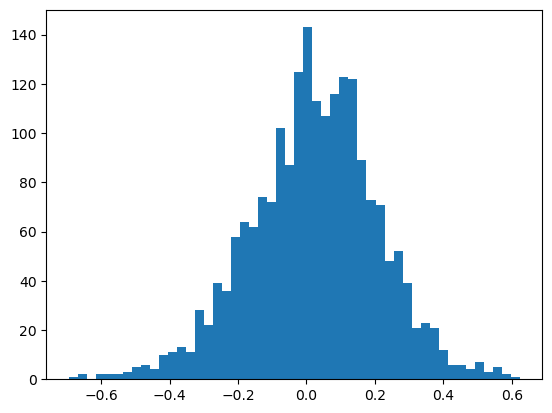

In [126]:
plt.hist(y_predicted, bins=50)

"ax = axs[2]\n\nax.add_feature(cfeature.COASTLINE)\nax.add_feature(cfeature.BORDERS)\nax.add_feature(cfeature.LAND)\n\ncyc_error, new_lons = add_cyclic_point(error.T, lons)\n\nim = ax.pcolormesh(new_lons+180, lats, cyc_error, cmap='Reds')\n\nfig.colorbar(im, orientation='horizontal', ax=ax, shrink=0.7)\nax.set_title('Error')\n\nfig.suptitle('Precipitation on Feb 1st, 2018')"

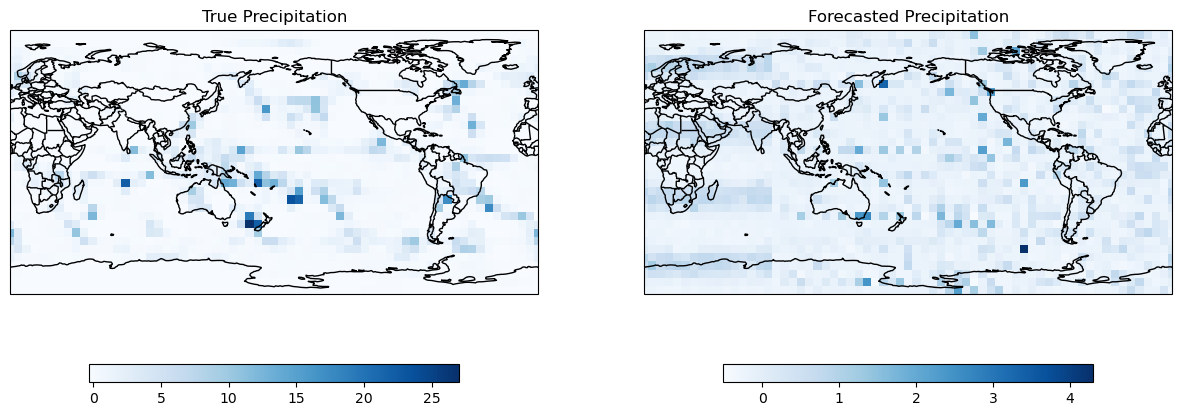

In [148]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cartopy.util import add_cyclic_point

fig, axs = plt.subplots(1, 2, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
#axs = axs.flatten()

## =====================
ax = axs[0]

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND)

true_tp, new_lons = add_cyclic_point(plot_y_true.T, lons)


im = ax.pcolormesh(new_lons+180, lats, true_tp, cmap='Blues')

fig.colorbar(im, orientation='horizontal', ax=ax, shrink=0.7)

ax.set_title('True Precipitation')

## =========================
ax = axs[1]

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND)

cyc_plot_y_pred, new_lons = add_cyclic_point(plot_y_pred.T, lons)

im = ax.pcolormesh(new_lons+180, lats, cyc_plot_y_pred, cmap='Blues')

fig.colorbar(im, orientation='horizontal', ax=ax, shrink=0.7)

ax.set_title('Forecasted Precipitation')

## ========================
'''ax = axs[2]

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND)

cyc_error, new_lons = add_cyclic_point(error.T, lons)

im = ax.pcolormesh(new_lons+180, lats, cyc_error, cmap='Reds')

fig.colorbar(im, orientation='horizontal', ax=ax, shrink=0.7)
ax.set_title('Error')

fig.suptitle('Precipitation on Feb 1st, 2018')'''

In [ ]:
dpt = full_ds.sel(time='2022-01-31T12:00:00') # datapoint

data_vals = torch.tensor(dpt.to_dataarray().values, dtype=torch.float32)

X = data_vals[:4]
y = data_vals[4]

X = X.permute(1, 2, 3, 0).reshape(-1, 4)
y = y.reshape(-1, 1)

Additional Exercises (Optional):
--------------------
1) Compare different architectures taking spatial patterns into account (CNN)
2) Add more variables from different vertical levels
3) Compare training on `np.log1p(tp)`

